In [1]:
#ST10365068
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split


In [11]:
#ST10365068
# Load the dataset
data = pd.read_csv("advanced_data.csv")
data.head()

,ID,Name,Age,Salary,Department
0,1,Alice,25.0,NaN,HR
1,2,Bob,NaN,55000.0,IT
2,3,Charlie,30.0,NaN,Finance
3,4,NaN,28.0,48000.0,HR
4,5,Eve,NaN,60000.0,IT


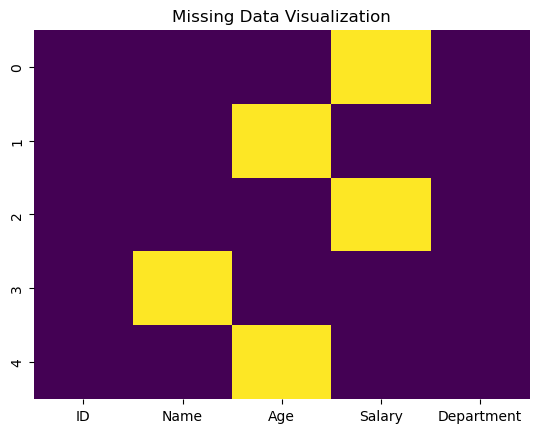

In [13]:
#ST10365068
# Visualize missing data
sns.heatmap(data.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Data Visualization")
plt.show()


In [14]:
#ST10365068
# Separate numeric and categorical columns
numeric_cols = ["Age", "Salary"]
categorical_cols = ["Name", "Department"]

# Handle missing numeric data using Random Forest Regressor
for col in numeric_cols:
    if data[col].isnull().sum() > 0:
        # Create training data excluding rows with missing values
        train_data = data[data[col].notnull()]
        test_data = data[data[col].isnull()]
        
        X_train = train_data.drop(columns=[col])
        y_train = train_data[col]
        
        # Drop irrelevant columns for prediction
        X_train = X_train.select_dtypes(include=np.number)
        
        # Train Random Forest model
        model = RandomForestRegressor()
        model.fit(X_train, y_train)
        
        # Predict missing values
        X_test = test_data.drop(columns=[col]).select_dtypes(include=np.number)
        data.loc[data[col].isnull(), col] = model.predict(X_test)


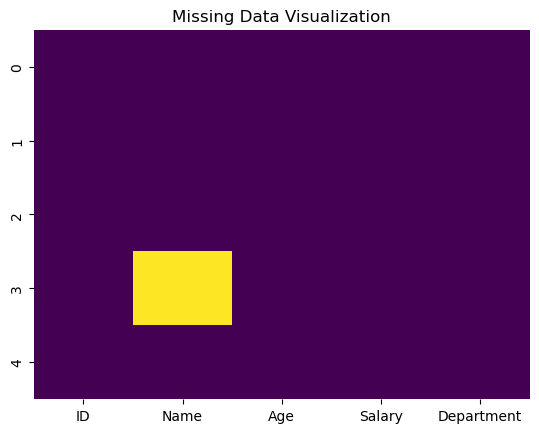

In [15]:
#ST10365068
# Visualize missing data
sns.heatmap(data.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Data Visualization")
plt.show()


In [16]:
#ST10365068
# Handle missing categorical data using mode
for col in categorical_cols:
    data[col].fillna(data[col].mode()[0])


In [17]:
#ST10365068
# Display the cleaned dataset
print("\nCleaned Dataset:")
print(data)



Cleaned Dataset:
   ID     Name    Age   Salary Department
0   1    Alice  25.00  53220.0         HR
1   2      Bob  26.23  55000.0         IT
2   3  Charlie  30.00  54140.0    Finance
3   4      NaN  28.00  48000.0         HR
4   5      Eve  28.31  60000.0         IT
